
🏆 LES 5 MEILLEURS CLONES DE HARRY KANE :


,player,Similarité (%)
8009,Kylian Mbappé,99.29
8696,Jonathan David,99.09
9530,Vinicius Júnior,98.08
8333,Loïs Openda,97.96
8859,Amine Gouiri,97.90


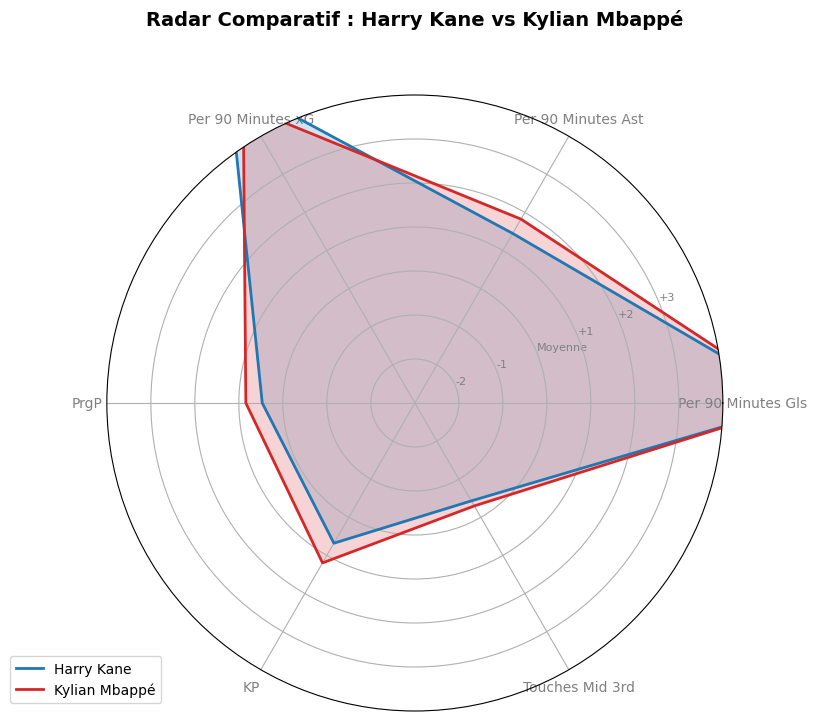

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# ==========================================
# ÉTAPE 1 : CHARGEMENT ET FILTRAGE CONTEXTUEL
# ==========================================
# 1. On charge le dataset final
df_final = pd.read_csv('/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv')
df_final.columns = df_final.columns.str.strip()

# --- NOUVEAU : LE FILTRE DE LA SAISON ---
# Remplace 'season' par le vrai nom de ta colonne si besoin, 
# et '2023-2024' par le format exact de l'année dans ta base.
df_final = df_final[df_final['season'] == 2023].copy()
# ----------------------------------------

# 2. Filtrage : On garde les joueurs pertinents (> 900 min)
df_season = df_final[df_final['Playing Time Min'] >= 900].copy()

# 3. Anti-Doublons (au cas où un joueur a changé de club en plein milieu de la saison 2023)
df_season = df_season.sort_values(by=['player', 'Playing Time Min'], ascending=[True, False])
df_season = df_season.drop_duplicates(subset=['player'], keep='first')
# ==========================================
# ÉTAPE 2 : CALCUL DES Z-SCORES
# ==========================================
# Définition de tes métriques clés (Profil Kane)
stats_to_plot = [
    'Per 90 Minutes Gls', 
    'Per 90 Minutes Ast', 
    'Per 90 Minutes xG', 
    'PrgP', 
    'KP', 
    'Touches Mid 3rd'
]

# Sécurité : on ne garde que les colonnes qui existent vraiment
stats_to_plot = [col for col in stats_to_plot if col in df_season.columns]

# Calcul des Z-scores
cols_zscore = []
for col in stats_to_plot:
    nom_colonne_z = f"{col}_zscore"
    # Calcul du (Valeur - Moyenne) / Ecart-type
    df_season[nom_colonne_z] = (df_season[col] - df_season[col].mean()) / df_season[col].std()
    df_season[nom_colonne_z] = df_season[nom_colonne_z].fillna(0)
    cols_zscore.append(nom_colonne_z)

# ==========================================
# ÉTAPE 3 : FONCTIONS DE SCOUTING & RADAR
# ==========================================
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# ÉTAPE 3 : FONCTIONS DE SCOUTING & RADAR (CORRIGÉE)
# ==========================================
def trouver_clones(joueur_cible, df, colonnes_z, top=5):
    """Trouve les profils les plus proches en utilisant la Similarité Cosinus."""
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # Isoler le profil du joueur cible (format matrice pour scikit-learn)
    cible_stats = df[df['player'] == joueur_cible][colonnes_z].values.reshape(1, -1)
    
    # Toutes les stats de tous les joueurs
    toutes_stats = df[colonnes_z].values
    
    # Calcul de la similarité cosinus (Angle entre les profils)
    similarities = cosine_similarity(cible_stats, toutes_stats)[0]
    
    # Création du DataFrame de résultats
    df_resultats = df[['player']].copy()
    df_resultats['Similarité (%)'] = np.round(similarities * 100, 2)
    
    # Exclure le joueur lui-même et trier
    df_resultats = df_resultats[df_resultats['player'] != joueur_cible]
    df_resultats = df_resultats.sort_values(by='Similarité (%)', ascending=False)
    
    return df_resultats.head(top)

def tracer_radar(joueur1, joueur2, df, colonnes_brutes):
    """Trace le radar chart superposant le joueur cible et son meilleur clone."""
    colonnes_z = [f"{c}_zscore" for c in colonnes_brutes]
    
    val1 = df[df['player'] == joueur1][colonnes_z].values[0].tolist()
    val2 = df[df['player'] == joueur2][colonnes_z].values[0].tolist()
    
    # Fermer le polygone
    val1 += val1[:1]
    val2 += val2[:1]
    
    angles = [n / float(len(colonnes_brutes)) * 2 * pi for n in range(len(colonnes_brutes))]
    angles += angles[:1]
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    
    # Tracé Joueur 1 (Bleu)
    ax.plot(angles, val1, linewidth=2, linestyle='solid', label=joueur1, color='#1f77b4')
    ax.fill(angles, val1, '#1f77b4', alpha=0.2)
    
    # Tracé Joueur 2 (Rouge)
    ax.plot(angles, val2, linewidth=2, linestyle='solid', label=joueur2, color='#d62728')
    ax.fill(angles, val2, '#d62728', alpha=0.2)
    
    plt.xticks(angles[:-1], colonnes_brutes, color='grey', size=10)
    plt.yticks([-2, -1, 0, 1, 2, 3], ["-2", "-1", "Moyenne", "+1", "+2", "+3"], color="grey", size=8)
    plt.ylim(-3, 4)
    
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(f"Radar Comparatif : {joueur1} vs {joueur2}", size=14, y=1.1, fontweight='bold')
    plt.show()

# ==========================================
# ÉTAPE 4 : EXÉCUTION
# ==========================================
joueur_a_scouter = "Harry Kane"
df_top5 = trouver_clones(joueur_a_scouter, df_season, cols_zscore, top=5)

print(f"\n🏆 LES 5 MEILLEURS CLONES DE {joueur_a_scouter.upper()} :")
display(df_top5)

# On trace le radar avec le n°1 du classement
meilleur_clone = df_top5.iloc[0]['player']
tracer_radar(joueur_a_scouter, meilleur_clone, df_season, stats_to_plot)

In [23]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# ==========================================
# L'ENTONNOIR DE SCOUTING (LA MÉTHODE PRO)
# ==========================================

def scouting_entonnoir(joueur_cible, df, colonnes_z, top=5):
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # 1. Filtre de Performance
    df_cible = df[df['player'] == joueur_cible].copy()
    df_candidats = df[df['Per 90 Minutes Gls'] >= 0.40].copy()
    
    if joueur_cible not in df_candidats['player'].values:
        df_candidats = pd.concat([df_candidats, df_cible])
        
    # 2. Le Filtre Tactique Sévere (Distance Euclidienne)
    cible_stats = df_candidats[df_candidats['player'] == joueur_cible][colonnes_z].values[0]
    
    resultats = []
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == joueur_cible:
            continue
            
        stats_actuelles = row[colonnes_z].values
        
        # Calcul de l'écart exact (Distance Euclidienne)
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        
        # Formule stricte : plus la distance augmente, plus le % chute drastiquement
        # (Diviser par la distance permet d'avoir des scores qui plafonnent de manière réaliste)
        similarite = max(0, 100 - (distance * 12)) 
        
        resultats.append({
            'Joueur': joueur_actuel,
            'Buts / 90min': row['Per 90 Minutes Gls'],
            'Similarité (%)': round(similarite, 2)
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarité (%)', ascending=False)
    return df_res.head(top)

# ==========================================
# EXÉCUTION DE L'ALGORITHME FUSIONNÉ
# ==========================================
joueur_a_scouter = "Harry Kane"

# On utilise les Z-Scores calculés précédemment
df_top5_fusion = scouting_entonnoir(joueur_a_scouter, df_season, cols_zscore, top=5)

print(f"\n🏆 TOP 5 CLONES DE {joueur_a_scouter.upper()} (Volume Élite + Style Créateur) :")
display(df_top5_fusion)


🏆 TOP 5 CLONES DE HARRY KANE (Volume Élite + Style Créateur) :


,Joueur,Buts / 90min,Similarité (%)
58,Kylian Mbappé,1.13,88.04
33,Erling Haaland,0.95,75.67
92,Serhou Guirassy,1.14,74.12
10,Artem Dovbyk,0.83,69.87
1,Alexander Isak,0.84,67.98



📊 Génération des graphiques en cours...



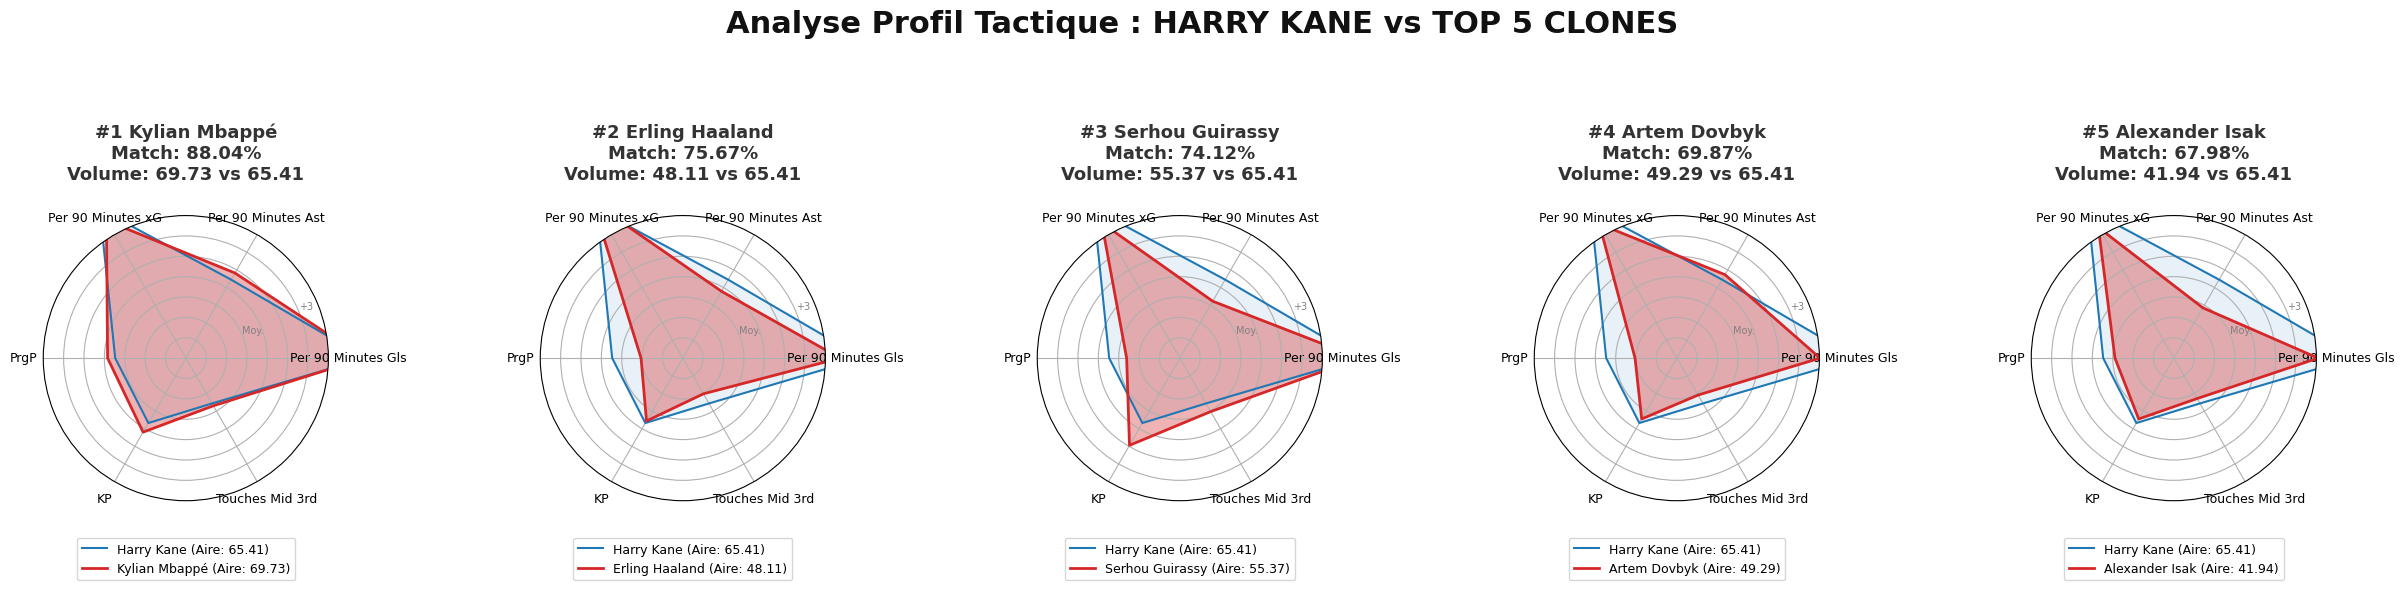

In [26]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

def calcul_aire_radar(valeurs_zscore):
    """Calcule l'aire du polygone (Volume de jeu) à partir des Z-scores."""
    n = len(valeurs_zscore) - 1 # -1 car la liste est bouclée pour le graphique
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        # On ajoute +3 pour que le centre du radar (qui est à -3) soit le 0 mathématique de l'aire
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars(joueur_cible, df_top5, df, colonnes_brutes):
    """Affiche une grille de 5 radars comparatifs avec calcul des aires."""
    colonnes_z = [f"{c}_zscore" for c in colonnes_brutes]
    
    # Récupérer et préparer les stats de Kane
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] # Fermer le polygone
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    # Préparer les angles du radar
    angles = [n / float(len(colonnes_brutes)) * 2 * pi for n in range(len(colonnes_brutes))]
    angles += angles[:1]
    
    # Créer la figure (1 ligne, 5 colonnes)
    fig, axs = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))
    fig.suptitle(f"Analyse Profil Tactique : {joueur_cible.upper()} vs TOP 5 CLONES", 
                 size=22, y=1.15, fontweight='bold', color='#111111')
    
    for i, (index, row) in enumerate(df_top5.iterrows()):
        joueur_compare = row['Joueur']
        
        # --- LA CORRECTION EST ICI ---
        # On utilise le bon nom de colonne généré par ton algorithme Euclidien
        similarite = row['Similarité (%)']
        # -----------------------------
        
        # Récupérer les stats du clone
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        
        # Tracer Kane (Ligne Bleue)
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', label=f"{joueur_cible} (Aire: {aire_cible})", color='#1f77b4')
        ax.fill(angles, valeurs_cible, '#1f77b4', alpha=0.1)
        
        # Tracer le Clone (Ligne Rouge)
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='solid', label=f"{joueur_compare} (Aire: {aire_compare})", color='#d62728')
        ax.fill(angles, valeurs_compare, '#d62728', alpha=0.35) 
        
        # Design du radar
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(colonnes_brutes, color='black', size=9) 
        ax.set_yticks([-2, -1, 0, 1, 2, 3])
        ax.set_yticklabels(["", "", "Moy.", "", "", "+3"], color="grey", size=7)
        ax.set_ylim(-3, 4)
        
        # Titre de chaque sous-graphique
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite}%\nVolume: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='#333333', y=1.1)
        
        # Ajouter la légende au centre de chaque radar
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), fontsize=9)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# EXÉCUTION DE L'AFFICHAGE MULTIPLE
# ==========================================
print("\n📊 Génération des graphiques en cours...\n")
visualiser_top5_radars("Harry Kane", df_top5_fusion, df_season, stats_to_plot)


📊 Génération des graphiques en cours...



KeyError: 'Similarité Tactique (%)'

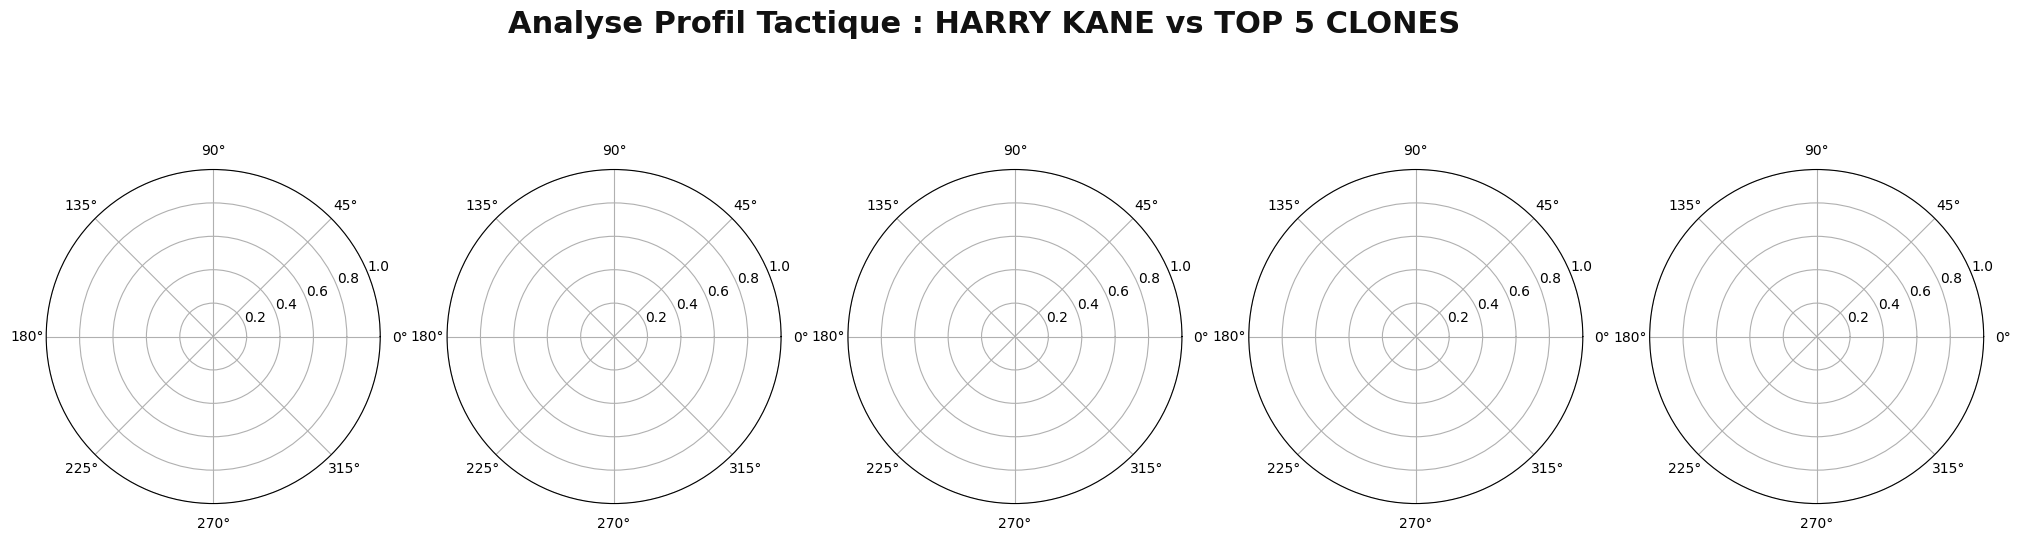

In [ ]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

def calcul_aire_radar(valeurs_zscore):
    """Calcule l'aire du polygone (Volume de jeu) à partir des Z-scores."""
    n = len(valeurs_zscore) - 1
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        # On ajoute +3 pour que le centre du radar (qui est à -3) soit le 0 mathématique de l'aire
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars_pro(joueur_cible, df_top5, df, colonnes_brutes):
    """Affiche une grille de 5 radars comparatifs (Dark Mode) avec calcul des aires."""
    # CORRECTION 1 : Le suffixe est '_z' maintenant, plus '_zscore'
    colonnes_z = [f"{c}_z" for c in colonnes_brutes] 
    
    # Récupérer et préparer les stats de la Cible
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] # Fermer le polygone
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    # Préparer les angles du radar
    angles = [n / float(len(colonnes_brutes)) * 2 * pi for n in range(len(colonnes_brutes))]
    angles += angles[:1]
    
    # --- DESIGN PRO (Dark Mode) ---
    couleur_fond = '#1b1d22'
    couleur_cible = '#00ffcc'     # Cyan
    couleur_candidat = '#ff3366'  # Rose
    
    # Créer la figure (1 ligne, 5 colonnes)
    fig, axs = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(couleur_fond)
    fig.suptitle(f"ANALYSE TACTIQUE : LES 5 MEILLEURS CLONES DE {joueur_cible.upper()}", 
                 size=24, y=1.15, fontweight='bold', color='white')
    
    for i, (index, row) in enumerate(df_top5.head(5).iterrows()):
        # CORRECTION 2 : Les bons noms de colonnes
        joueur_compare = row['player'] 
        similarite = row['Similarite_Score'] 
        
        # Récupérer les stats du clone
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        ax.set_facecolor(couleur_fond)
        
        # CORRECTION 3 : Fixer le centre à -3 pour éviter les "sabliers"
        ax.set_rmin(-3)
        ax.set_rmax(3)
        ax.grid(color='#3a3f48', linestyle='--', linewidth=1)
        ax.spines['polar'].set_color(couleur_fond)
        
        # Tracer la Cible (Ligne Cyan)
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', label=f"{joueur_cible} (Vol: {aire_cible})", color=couleur_cible)
        ax.fill(angles, valeurs_cible, couleur_cible, alpha=0.15)
        
        # Tracer le Clone (Ligne Rose)
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='dashed', label=f"{joueur_compare} (Vol: {aire_compare})", color=couleur_candidat)
        ax.fill(angles, valeurs_compare, couleur_candidat, alpha=0.25) 
        
        # Design des axes
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(colonnes_brutes, color='white', size=9, fontweight='bold')
        ax.tick_params(axis='x', pad=15)
        
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels(["", "", "Moy.", "", ""], color="#888888", size=8)
        
        # Titre de chaque sous-graphique
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite:.1f}%\nVolume: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='white', y=1.15)
        
        # Légende
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=10, 
                  facecolor=couleur_fond, edgecolor=couleur_fond, labelcolor='white')
            
    plt.tight_layout()
    plt.show()

# ==========================================
# EXÉCUTION DE L'AFFICHAGE MULTIPLE
# ==========================================
print("\n📊 Génération de la grille des Radars Pro en cours...\n")
# CORRECTION 4 : Utiliser les variables actuelles (JOUEUR_CIBLE, df_top_clones, df_saison, kpi_scouting)
visualiser_top5_radars_pro(JOUEUR_CIBLE, df_top_clones, df_saison, kpi_scouting)

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def scouting_hybride(joueur_cible, df, colonnes_z, top=5):
    """L'algorithme Ultime : Combine le Style Tactique (Cosinus) et le Volume (Euclidienne)."""
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # 1. Le Filtre de Buteurs (On garde les bons finisseurs > 0.40 buts/90)
    df_cible = df[df['player'] == joueur_cible].copy()
    df_candidats = df[df['Per 90 Minutes Gls'] >= 0.40].copy()
    if joueur_cible not in df_candidats['player'].values:
        df_candidats = pd.concat([df_candidats, df_cible])
        
    cible_stats = df_candidats[df_candidats['player'] == joueur_cible][colonnes_z].values[0]
    cible_stats_matrice = cible_stats.reshape(1, -1)
    
    resultats = []
    
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == joueur_cible:
            continue
            
        stats_actuelles = row[colonnes_z].values
        stats_matrice = stats_actuelles.reshape(1, -1)
        
        # --- A. LE SCORE TACTIQUE (Cosinus) ---
        # Note l'angle du radar (Est-ce qu'il décroche et fait des passes comme Kane ?)
        score_tactique = cosine_similarity(cible_stats_matrice, stats_matrice)[0][0]
        # On le remet sur 100
        note_tactique = max(0, score_tactique * 100)
        
        # --- B. LE SCORE DE VOLUME (Euclidienne) ---
        # Note la distance (Est-ce qu'il marque autant et produit autant de jeu ?)
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        note_volume = max(0, 100 - (distance * 12)) 
        
        # --- C. LE SCORE HYBRIDE FINAL ---
        # On donne 60% d'importance au Style Tactique, et 40% au Volume
        score_final = (note_tactique * 0.60) + (note_volume * 0.40)
        
        resultats.append({
            'Joueur': joueur_actuel,
            'Buts / 90min': row['Per 90 Minutes Gls'],
            'Score Tactique': round(note_tactique, 1),
            'Score Volume': round(note_volume, 1),
            'Similarité Globale (%)': round(score_final, 2)
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarité Globale (%)', ascending=False)
    return df_res.head(top)

# Exécution du modèle Hybride
df_top5_ultime = scouting_hybride("Harry Kane", df_season, cols_zscore, top=5)
display(df_top5_ultime)

,Joueur,Buts / 90min,Score Tactique,Score Volume,Similarité Globale (%)
58,Kylian Mbappé,1.13,99.3,88.0,94.79
33,Erling Haaland,0.95,96.9,75.7,88.40
92,Serhou Guirassy,1.14,96.5,74.1,87.52
10,Artem Dovbyk,0.83,96.6,69.9,85.93
61,Loïs Openda,0.80,98.0,67.3,85.69
